# 13 — The reasoning of an investigation

Twelve notebooks answer *what does this graph do*. None of them answers **what
was I trying to find out** — and that is the half an investigation actually
loses. A repository keeps every edit and no motive. A store keeps every number
and no question. Six months later the code is readable, the results are
readable, and why anybody ran them is gone.

Two layers, and one rule decides which anything belongs to:

> **If it can be recalculated it is record. If somebody thought it it is
> reasoning.**

Commits, the graph at each of them, what an edit did node by node — nobody types
those, they are worked out. The questions, the hypotheses, what was tried, what
the evidence said, what was decided — no amount of reading the repository
recovers them.

The two halves are used from different places, and that is not taste:

| | where |
|---|---|
| asking, supposing, trying, finding, deciding | the **terminal** — it happens while somebody is thinking, one at a time |
| reading it back and drawing it | the **library**, and this notebook |

So this notebook shells out to `somatize-tree` to write, and everything after
that is `somatize.reasoning`.

## What this needs

The command, which the wheel does not carry — it is a binary, and a wheel has no
use for an argument parser:

```bash
cargo build --release -p somatize-tree      # or: cargo install --path soma-tree
```

Everything else is `git`, which you have, and a repository made up below.

In [1]:
import json
import os
import pathlib
import shutil
import subprocess
import tempfile

from somatize import Store, reasoning

TREE = shutil.which("somatize-tree") or next(
    (str(p) for p in [
        pathlib.Path("../target/release/somatize-tree"),
        pathlib.Path("../target/debug/somatize-tree"),
    ] if p.exists()),
    None,
)
assert TREE, "build it: cargo build --release -p somatize-tree"
print(TREE)

../target/release/somatize-tree


## A repository with a history

Four commits on one line and two variants off it — the shape an investigation
has: one idea, several things tried from it. Hours apart on purpose, because
commits made in the same second send `git rev-list` back to the order it
traverses refs, which is their **names**, and branches would come out
alphabetical while looking chronological.

Nothing here is special. It is a graph, four nodes, every knob through a
constructor.

In [2]:
WHERE = pathlib.Path(tempfile.mkdtemp(prefix="soma-reasoning-"))
REPO, KEPT = WHERE / "repo", WHERE / "store"
(REPO / "experiments").mkdir(parents=True)


def git(*args, when=None):
    at = {"GIT_AUTHOR_DATE": when, "GIT_COMMITTER_DATE": when} if when else {}
    said = subprocess.run(
        ["git", "-C", str(REPO), *args],
        capture_output=True, text=True, env={**os.environ, **at},
    )
    assert said.returncode == 0, said.stderr
    return said.stdout.strip()


GRAPH = '''
from somatize import Graph, Node


class Tokenize(Node):
    def forward(self, x, ctx):
        return x.split()


class Classify(Node):
    def __init__(self, threshold=1.0):
        self.threshold = threshold

    def forward(self, x, ctx):
        return sum(1 for w in x if len(w) > self.threshold)


class Vote(Node):
    def forward(self, x, ctx):
        return max(x.values()) if isinstance(x, dict) else x


def build():
    return Graph.somatize(
        Tokenize().named("tokenize")
        >> (Classify(4.0).named("strict") | Classify(2.0).named("loose"))
        >> Vote().named("vote")
    )
'''

(REPO / "soma-tree.toml").write_text(
    'build = "experiments.encoder:build"\ntree = "spam"\n'
)
(REPO / "experiments" / "encoder.py").write_text(GRAPH)
git("init", "-q", ".")
git("config", "user.email", "you@example.com")
git("config", "user.name", "You")
git("add", "-A")
git("commit", "-qm", "base: tokenize, two classifiers, a vote", when="2026-08-20T09:00:00")
BASE = git("rev-parse", "HEAD")

(REPO / "experiments" / "encoder.py").write_text(GRAPH.replace("Classify(2.0)", "Classify(1.0)"))
git("commit", "-qam", "the loose classifier goes down to 1.0", when="2026-08-20T11:00:00")
LOOSE = git("rev-parse", "HEAD")

git("checkout", "-q", "-b", "no-vote", BASE)
(REPO / "experiments" / "encoder.py").write_text(GRAPH.replace('>> Vote().named("vote")', ""))
git("commit", "-qam", "drop the vote: read both classifiers directly", when="2026-08-20T13:00:00")
NOVOTE = git("rev-parse", "HEAD")
git("checkout", "-q", "master")

print(git("log", "--oneline", "--all", "--graph"))

* 500b0d5 drop the vote: read both classifiers directly
| * 654d52c the loose classifier goes down to 1.0
|/  
* 42958f2 base: tokenize, two classifiers, a vote


## Writing it down, one move at a time

Five kinds, and there are no more. Each verb writes one, and each one carries a
**name its author chooses** — because the store's slot identifies a move for
exactly as long as somebody holds it in a variable, and picking an investigation
up again a week later is the normal case.

| verb | kind | what only it can do |
|---|---|---|
| `ask` | question | the only one that can stand with nothing under it |
| `suppose` | hypothesis | gets **validated** or **refuted**, verbs a question does not have |
| `tried` | attempt | the only one that touches the record |
| `found` | finding | where the verb edges come from |
| `decide` | decision | apart from the finding, because two people can agree on one and disagree on the other |

In [3]:
def tree(*args):
    said = subprocess.run(
        [TREE, *args, "--repo", str(REPO), "--store", str(KEPT), "--tree", "spam"],
        capture_output=True, text=True,
    )
    assert said.returncode == 0, said.stderr
    return said.stdout.strip()


tree("ask", "thresholds", "-m",
     "The strict classifier fires on almost nothing under ten words. "
     "Is one threshold enough for both short and long messages?")
tree("suppose", "vote-helps", "-m",
     "A loose classifier voting with the strict one recovers the short texts "
     "without losing the long ones.",
     "--under", "thresholds");

### Two situations, and each is a question of its own

This is the one thing worth getting right, and it is what makes the interesting
answer sayable at all. A scope is a set of **moves** — *the whole encoder
branch* is a root, the whole investigation is none — so *it holds for short
texts and not for long ones* only becomes an answer when short and long are
moves. Put both halves at the same scope and the model says two people are
disagreeing, which is not what happened.

In [4]:
tree("ask", "short", "-m",
     "Under ten words: does the vote recover what the strict classifier misses?",
     "--under", "thresholds")
tree("ask", "long", "-m",
     "Over forty words: does the loose channel cost precision?",
     "--under", "thresholds")

tree("tried", "base", "-m", "The base: strict at 4.0, loose at 2.0, a vote on top.",
     "--under", "vote-helps", "--cites", BASE)
tree("tried", "loose-1-short", "-m", "Loose down to 1.0, scored on the short half.",
     "--under", "short", "--cites", LOOSE)
tree("tried", "loose-1-long", "-m", "The same commit, scored on the long half.",
     "--under", "long", "--cites", LOOSE)
tree("tried", "no-vote", "-m", "Drop the vote entirely and read both classifiers.",
     "--under", "thresholds", "--cites", NOVOTE)

tree("found", "short-recovered", "-m",
     "71% of texts under ten words now fire, against 12% before. The vote picks it up.",
     "--under", "loose-1-short")
tree("found", "long-noisier", "-m",
     "Nine points of false positives over forty words: the loose channel votes on everything.",
     "--under", "loose-1-long")

tree("says", "short-recovered", "validates", "vote-helps", "--about", "short")
tree("says", "long-noisier", "refutes", "vote-helps", "--about", "long")
tree("says", "short-recovered", "answers", "short")
tree("says", "long-noisier", "answers", "long");

### And the question neither of the two contained

Two live lines, and then: *what if I do both at once?* That attempt hangs under
**both**. With a single parent you either choose or duplicate the node, and a
duplicated node is two nodes that drift apart — which is the whole reason this
is a DAG.

Which attempts it is *made of* is a different edge: `combines`. That is what
makes *each one worked alone, together they cancel* readable as what it is,
rather than as two results that happen to sit near each other.

In [5]:
tree("ask", "why-strict", "-m",
     "Does moving the strict threshold change what the loose channel sees, or only the count?")
tree("tried", "strict-2", "-m", "Strict down to 2.0, same loose.",
     "--under", "why-strict", "--cites", BASE)
tree("tried", "both", "-m", "Strict at 2.0 AND the loose threshold at 1.0.",
     "--under", "why-strict", "--under", "short")
tree("says", "both", "combines", "loose-1-short")
tree("says", "both", "combines", "strict-2")
tree("found", "cancel", "-m",
     "Together they cancel: at 2.0 the strict channel already fires on the short "
     "texts, so the loose one adds nothing but the false positives.",
     "--under", "both")
tree("says", "cancel", "answers", "why-strict");

## Reading it back from the terminal

Nine verbs that write and no way to read them is a tool you cannot check your own
typing against. One line per move, indented by what it hangs under.

In [6]:
print(tree("moves"))

thresholds · question · open · The strict classifier fires on almost nothing under ten words. I…
  vote-helps · hypothesis · depends · A loose classifier voting with the strict one recovers the short…
    base · attempt · The base: strict at 4.0, loose at 2.0, a vote on top.
  short · question · answered · Under ten words: does the vote recover what the strict classifie…
    loose-1-short · attempt · Loose down to 1.0, scored on the short half.
      short-recovered · finding · 71% of texts under ten words now fire, against 12% before. The v…
    both · attempt · Strict at 2.0 AND the loose threshold at 1.0.
      cancel · finding · Together they cancel: at 2.0 the strict channel already fires on…
  long · question · answered · Over forty words: does the loose channel cost precision?
    loose-1-long · attempt · The same commit, scored on the long half.
      long-noisier · finding · Nine points of false positives over forty words: the loose chann…
  no-vote · attempt · Drop the vote e

## And as data

`somatize.reasoning` reads the same answer the outline was printed from — one
derivation, two readers, so an outline and a figure cannot disagree about what an
investigation contains.

Everything cross-references by **name**. The id is there because it says which of
two variants was tried first, and nothing else.

In [7]:
store = Store(str(KEPT))
rows = reasoning.moves(store, tree="spam")
[(one["name"], one["kind"], one["under"]) for one in rows][:6]

[('thresholds', 'question', []),
 ('vote-helps', 'hypothesis', ['thresholds']),
 ('short', 'question', ['thresholds']),
 ('long', 'question', ['thresholds']),
 ('base', 'attempt', ['vote-helps']),
 ('loose-1-short', 'attempt', ['short'])]

### How it stands, and why

Standing is **derived and never stored**. A field somebody overwrites loses the
previous fact, and the previous fact is what a standing goes back to.

In [8]:
reasoning.standing(store, tree="spam")

{'thresholds': 'open',
 'vote-helps': 'depends',
 'short': 'answered',
 'long': 'answered',
 'why-strict': 'answered'}

`depends` is the answer this whole model exists to be able to give: validated in
some situations and refuted in others **without the scopes touching**. Not half
an answer and not a conflict — the answer depending on the case, which is the
most informative outcome an investigation gives.

`covered` is what tells it from a dispute, and it is the one walk you cannot redo
by hand and get right: `under` is multivalued, so a scope is a DAG and not a
subtree.

In [9]:
short = reasoning.covered(store, tree="spam", by=["short"])
long_ = reasoning.covered(store, tree="spam", by=["long"])
print("short:", short)
print("long :", long_)
print("touching:", set(short) & set(long_) or "nothing — so it depends, and is not disputed")

short: ['short', 'loose-1-short', 'short-recovered', 'both', 'cancel']
long : ['long', 'loose-1-long', 'long-noisier']
touching: nothing — so it depends, and is not disputed


Put both halves at the same scope instead and the same two edges come out
`disputed`, which reads as two people disagreeing rather than as an answer with a
domain. Saying an edge again corrects its scope rather than duplicating it, so
this is reversible:

In [10]:
tree("says", "long-noisier", "refutes", "vote-helps", "--about", "short")
print("same scope:", reasoning.standing(store, tree="spam")["vote-helps"])

tree("says", "long-noisier", "refutes", "vote-helps", "--about", "long")
print("put back  :", reasoning.standing(store, tree="spam")["vote-helps"])

same scope: disputed
put back  : depends


## Drawn

Depth grows to the right and siblings stack downward, because a move carries
prose and columns two words across cannot be read. Nothing is draggable and no
axis is a preference: this draws something that already happened, so a position
is derived from the shape — one somebody dragged would have to be stored, and it
is not a fact about the investigation.

Hue says which of the five kinds a move is and **never** whether it went well;
how a question stands is written on it, in words. Hover for the prose.

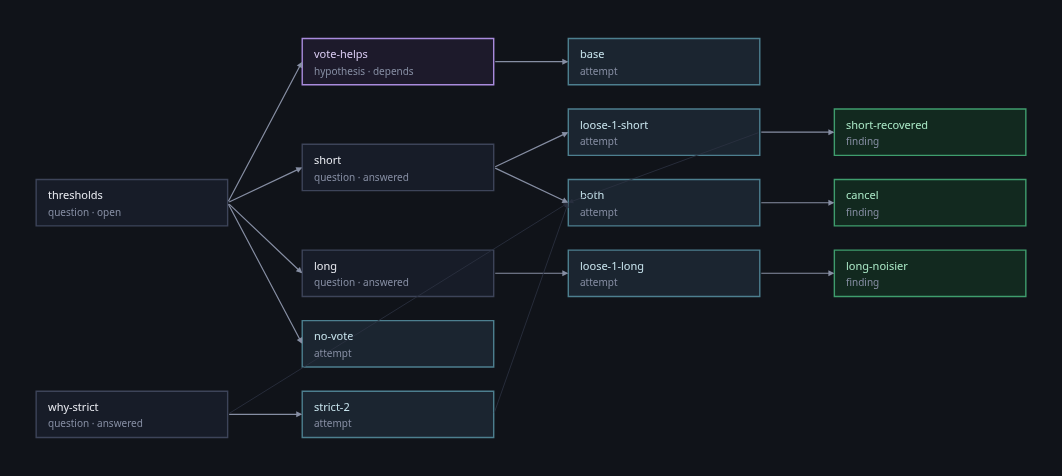

In [11]:
reasoning.figure(store, tree="spam")

Solid is the line a move hangs on. Dashed is a **second parent** — `both` answers
two questions and neither is the parent. Dotted is `combines`, the two attempts
it is made of.

`loose-1-short` is on the figure once and pointed at twice. In an indented
outline that could only have been said in words.

## What was abandoned, and what folds

Two ways a line disappears and they are not the same control. A **pruned** line
comes folded because somebody decided to abandon it, and it says how many it
hides and **why**, in words.

The scope of a decision names **what is abandoned** — and what is abandoned has
to be a move, an attempt nobody ever ran included, which is precisely the one you
need to be able to say was never run.

In [12]:
tree("decide", "abandon", "drop-no-vote", "-m",
     "Reading both classifiers without a vote needs a rule downstream that "
     "nobody has, and the vote is cheaper.",
     "--about", "no-vote")

tree("tried", "per-length", "-m",
     "A threshold picked from the token count. Never ran.",
     "--under", "thresholds")
tree("decide", "abandon", "drop-per-length", "-m",
     "A threshold that depends on the input is a second model, and this was "
     "meant to be one knob.",
     "--about", "per-length")

reasoning.folds(store, tree="spam")

[{'root': 'no-vote',
  'by': 'drop-no-vote',
  'course': 'abandon',
  'why': 'Reading both classifiers without a vote needs a rule downstream that nobody has, and the vote is cheaper.',
  'hides': ['no-vote']},
 {'root': 'per-length',
  'by': 'drop-per-length',
  'course': 'abandon',
  'why': 'A threshold that depends on the input is a second model, and this was meant to be one knob.',
  'hides': ['per-length']}]

`per-length` cites no commit — nobody ran it — so nothing worked out from the
**record** could ever have said it was abandoned. What folds is derived over the
moves, and reaches it.

Pruning never deletes. Hand the figure no folds and the whole thing is open:

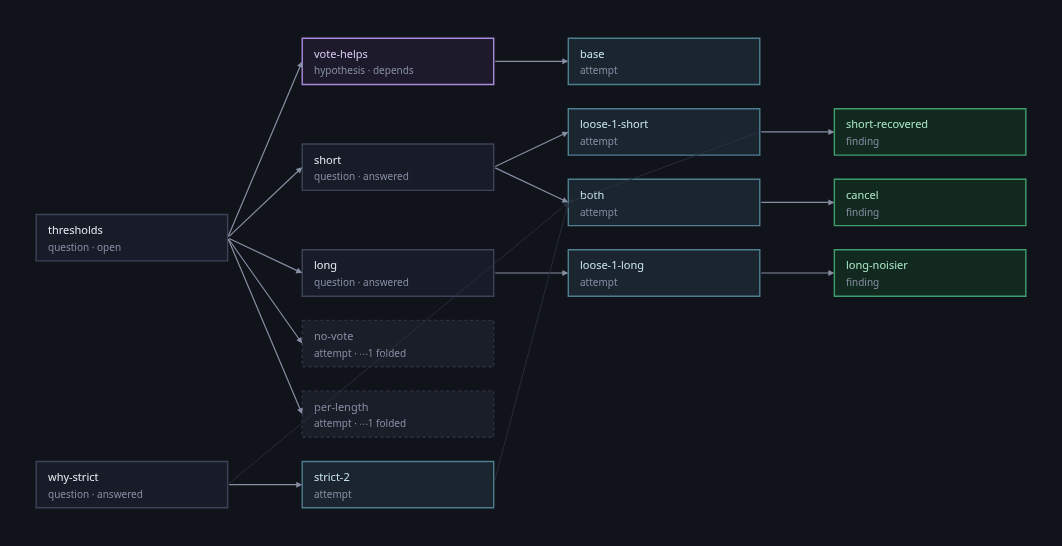

In [13]:
reasoning.figure(store, tree="spam")

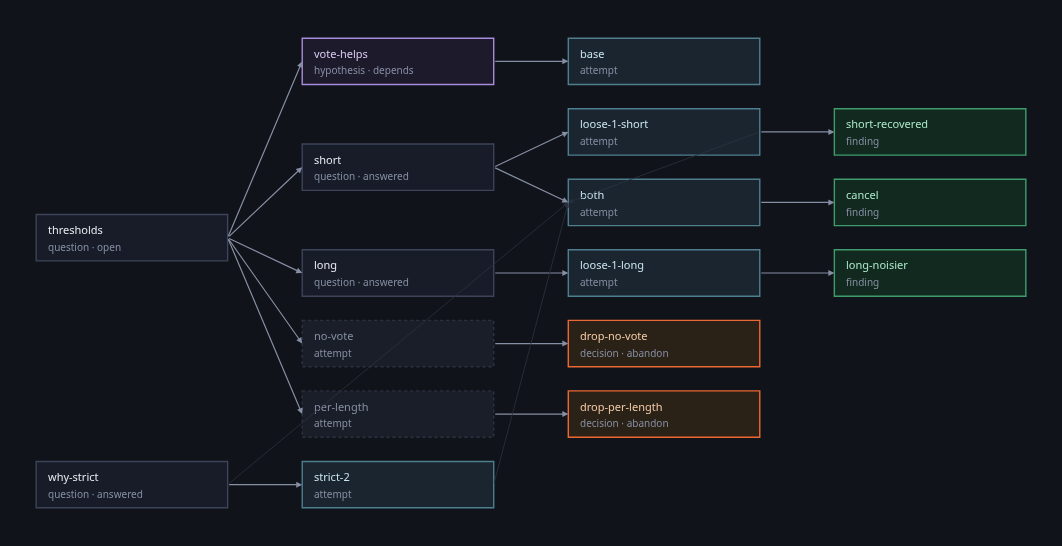

In [14]:
reasoning.figure(store, tree="spam", folded=False)

Folding what you have **read** is not in this library and will not be. It writes
nothing down, because closing what you have read is not a claim about the
investigation — it is the reader's, and so it is an app's. Which is what the
split below is for: the layout is a pure function of the rows, so folding is
simply *what you hand it*.

In [15]:
moves, says, folds = (
    reasoning.moves(store, tree="spam"),
    reasoning.says(store, tree="spam"),
    reasoning.folds(store, tree="spam"),
)
for handed, what in [(folds, "both folded"), (folds[:1], "one of them"), ([], "nothing folded")]:
    drawn, _ = reasoning.cards(moves, says, handed)
    print(f"{what:14} -> {len(drawn)} cards")

both folded    -> 15 cards
one of them    -> 16 cards
nothing folded -> 17 cards


## Going back to try another idea

`git checkout` asks for a hash. What anybody remembers is the idea.

A commit is only half of what ran, too: the same one under two configurations is
two experiments, and git does not have that half. So it is kept beside the
citation, and both come back.

In [16]:
config = WHERE / "invocation.txt"
config.write_text("run.py --threshold-strict 2.0 --threshold-loose 1.0\n")
digest = tree("keep", str(config))

tree("tried", "strict-2-loose-1", "-m", "Both knobs at once, run for real.",
     "--under", "why-strict", "--cites", LOOSE, "--ran", digest)

print(tree("go", "strict-2-loose-1"))

strict-2-loose-1 · at 654d52cc1ec6 · Both knobs at once, run for real.

  ran with:
    run.py --threshold-strict 2.0 --threshold-loose 1.0


A branch of its own, and never an existing one: a commit is a version that has
already been measured, so arriving at one is arriving to make the **next**
variant, not to rewrite that one. Unstaged work is a refusal rather than
something carried along.

Which is also why there is no `fork` verb and will not be. In a browser you
cannot edit files, so the original had to splice one, commit and branch, and
called it forking. Here the person typing holds the checkout: `go`, then edit,
then commit.

In [17]:
print(subprocess.run(["git", "-C", str(REPO), "branch", "--show-current"],
                     capture_output=True, text=True).stdout)

strict-2-loose-1



### And the way back

A commit you cannot ask *what was this for* is a change without a motive. It is
derived from the citations and kept in **no index**, so it is true the moment
somebody cites it and cannot go stale.

In [18]:
print(tree("here", LOOSE))
print()
reasoning.cites(store, tree="spam")["commit"][LOOSE]

654d52cc1ec6
  loose-1-short · attempt · Loose down to 1.0, scored on the short half.
  loose-1-long · attempt · The same commit, scored on the long half.
  strict-2-loose-1 · attempt · Both knobs at once, run for real.



['loose-1-short', 'loose-1-long', 'strict-2-loose-1']

## A standing that comes back on its own

This is what being derived buys, and the case is the one worth having: a
refutation read off a measurement that lied.

`invalid` is a judgement about the **code**, so it lives in the journal and is
deliberately not one of the three courses a decision carries. Marking a commit
invalid withdraws what rests on it — the attempt that cited it, and the finding
hanging under that attempt — and the hypothesis goes back to `open` with nobody
saying anything again.

In [19]:
tree("verdict", "invalid", LOOSE, "-m",
     "The short/long split was computed on the wrong column.")

print("standing:", reasoning.standing(store, tree="spam")["vote-helps"])
[(one["from"], one["says"], one["to"], one["withdrawn"])
 for one in reasoning.says(store, tree="spam")
 if one["says"] in ("validates", "refutes")]

standing: open


[('short-recovered', 'validates', 'vote-helps', True),
 ('long-noisier', 'refutes', 'vote-helps', True)]

Nothing was deleted: the edges are still written and still drawn, and they say
why they stopped counting. A later `sound` puts them back, because the journal
keeps the last word.

In [20]:
tree("verdict", "sound", LOOSE, "-m", "I misread it: the column was right.")
reasoning.standing(store, tree="spam")["vote-helps"]

'depends'

Nothing ran again in any of that. The reasoning is drawn from what is stored,
which is the invariant this whole layer is built to keep: **a diagnosis has to
be reproducible from the stored record, without training again.** Change your
mind about a verdict and ask again; the record has not moved.

## Where the line is

**Deriving is the framework's**: the layout of the DAG, the standing of every
question, whether two scopes touch, what cites what, which lines are folded
because somebody abandoned them.

**Interacting is an app's**: folding what you have read, clicking through,
editing. None of it is in here, and none of it will be — soma does not mount a
server.

| | |
|---|---|
| `moves`, `says`, `folds`, `standing` | what is written down, derived, in names |
| `covered` | what a scope reaches, so *do these touch* is an intersection |
| `cites` | the way back, kept in no index |
| `cards` | where every box goes — pure over the rows above |
| `figure` | the same, drawn |

In [21]:
shutil.rmtree(WHERE)